In [1]:
import qsharp
import random
import json
from diskcache import Cache

cache = Cache("~/quant-arith-cache/")
qsharp.init(project_root="../")

@cache.memoize()
def estimate_resources_in_place_adder(op, n):
    est = qsharp.estimate(f"EstimateUtils.RunBinaryOpInPlace({n},{op})")
    return json.dumps(est)    

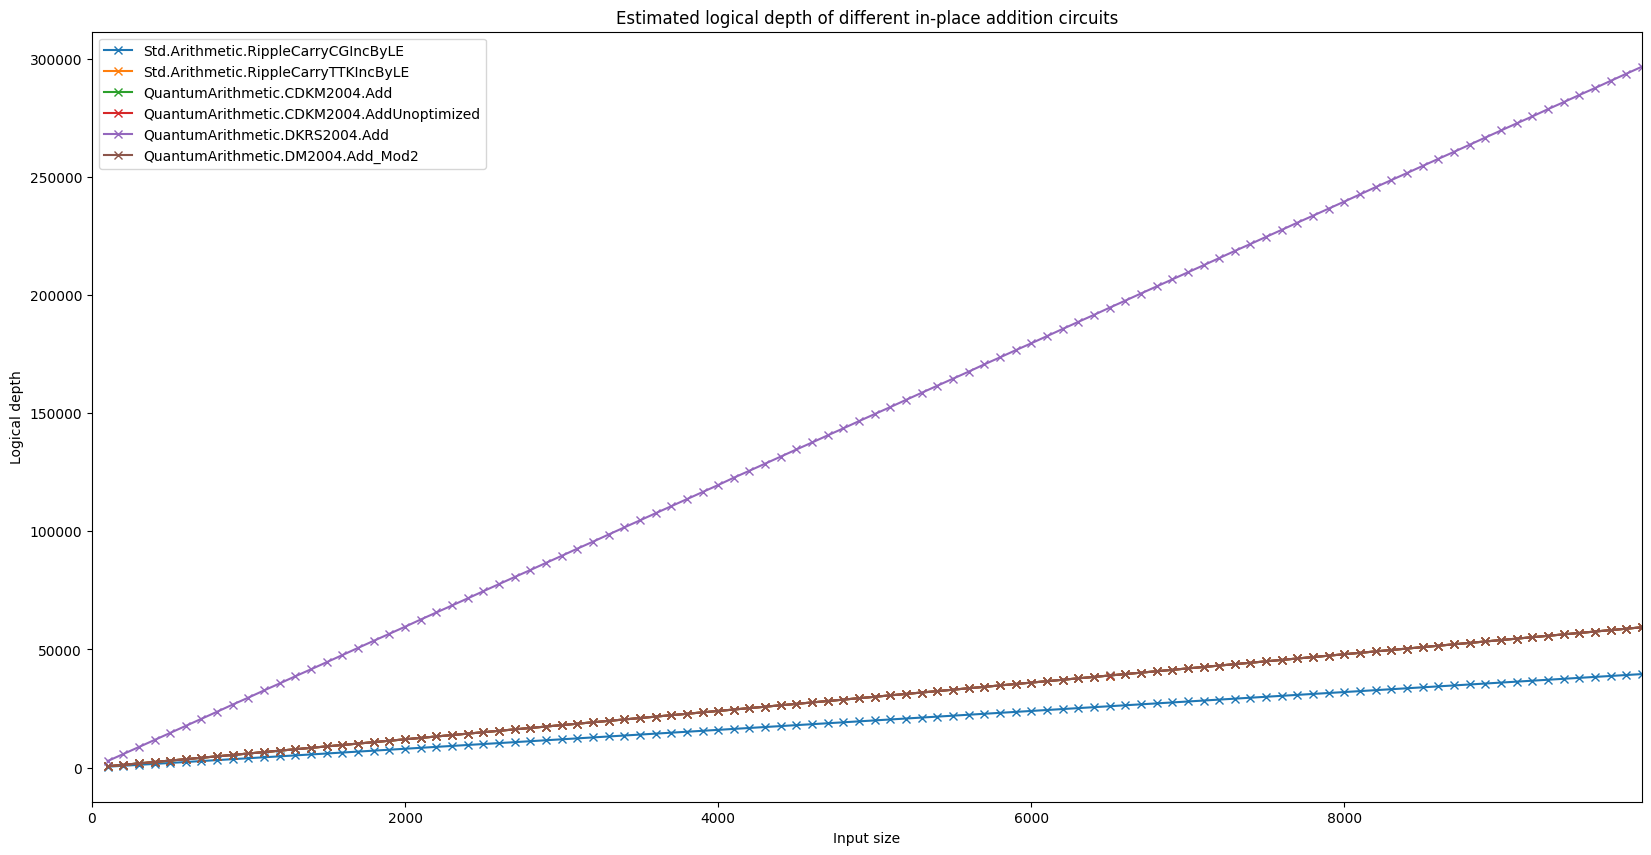

In [9]:
# These all are in-place adders modulo 2^n.
ops = [
  "Std.Arithmetic.RippleCarryCGIncByLE",
  "Std.Arithmetic.RippleCarryTTKIncByLE",
    #"Std.Arithmetic.FourierTDIncByLE",
  "QuantumArithmetic.CDKM2004.Add",
  "QuantumArithmetic.CDKM2004.AddUnoptimized",
  "QuantumArithmetic.DKRS2004.Add",
  "QuantumArithmetic.DM2004.Add_Mod2",
]

depth_chart = {op: [] for op in ops}
runtime_chart = {op: [] for op in ops}
n_range = list(range(100, 10000, 100))
import time

for n in n_range:
    t0 =time.time()
    for op in ops:
        estimates = json.loads(estimate_resources_in_place_adder(op, n))
        runtime_chart[op].append(estimates['physicalCounts']['runtime'])
        depth_chart[op].append(estimates['physicalCounts']['breakdown']['logicalDepth'])
    #print(n, time.time()-t0, flush=True)

from matplotlib import pyplot as plt

plt.figure(figsize=(20, 10))
for op in ops:
    plt.plot(n_range, depth_chart[op], label=op, marker='x')
plt.xlim([0,max(n_range)])
plt.legend()
plt.xlabel('Input size')
plt.ylabel('Logical depth')
plt.title('Estimated logical depth of different in-place addition circuits')
plt.show()